# Generate annual/yearly zarr stores from hourly ERA5 data on NCAR's GDEX


## Overview and Warning: Please Read
- [ERA5 data](https://gdex.ucar.edu/datasets/d633000/) on NCAR's Geoscience Data Exchange (GDEX) is stored in hourly NetCDF files. But, kerchunk reference files have been created for pressure level data and zarr stores have been created for the surface variables to convert this dataset into an ARCO collection.
- In this notebook, we will read hourly data from NCAR's publicly accessible ERA5 collection using an intake-ESM catalog, compute the annual means and store the result using zarr stores.
- If you don't have write permision to save to NCAR's GDEX, please save the result to your local folder.
- If you need annual means for the following variables, please don't run the commented cells in this notebook. The data has already been calculated and can be accessed via https from https://data.gdex.ucar.edu/special_projects/pythia_2024/annual_means/

  1) Air temperature at 2 m/ [VAR_2T](https://data.gdex.ucar.edu/special_projects/pythia_2024/annual_means/temp_2m_annual_1940_2023.zarr)
     
- Otherwise, please run this script once to generate the annual means.

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Xarray](https://foundations.projectpythia.org/core/xarray) | Necessary | |
| [Intro to Intake](https://projectpythia.org/intake-cookbook/notebooks/intake_introduction) | Necessary | |
| [Understanding of Zarr](https://zarr.readthedocs.io/en/stable/) | Helpful | |

- **Time to learn**: 30 minutes

## Imports

In [1]:
import glob
import re
import matplotlib as plt
import numpy as np
import scipy as sp
import xarray as xr
import intake
import intake_esm
import pandas as pd

In [2]:
import dask
from dask.distributed import Client, performance_report,LocalCluster
from dask_jobqueue import PBSCluster

In [3]:
######## File paths ################
gdex_scratch   = "/glade/derecho/scratch/harshah"
era5_catalog = 'https://data.gdex.ucar.edu/d633000/catalogs/d633000-https.json'
daily_means = "../data/ERA5_2T/daily_means/"
# annual_means      = '/gdex/data/special_projects/pythia_2024/annual_means/' #Posix path, only used for writing data 
# annual_means_https= 'https://data.gdex.ucar.edu/special_projects/pythia_2024/annual_means/'

print(era5_catalog)

https://data.gdex.ucar.edu/d633000/catalogs/d633000-https.json


In [10]:
ds = xr.open_dataset("https://data.gdex.ucar.edu/d633000/e5.oper.an.sfc.zarr", engine='zarr')

GroupNotFoundError: No group found in store 'https://data.gdex.ucar.edu/d633000/e5.oper.an.sfc.zarr' at path ''

In [12]:
ds = xr.open_dataset("https://dtn-pas.denv.nrp.internet2.edu:8443/ncar/gdex/d633000/e5.oper.an.sfc.zarr/e5.oper.an.sfc.2t.zarr/", engine='zarr')
ds

<xarray.Dataset> Size: 3TB
Dimensions:            (time: 749472, latitude: 721, longitude: 1440)
Coordinates:
  * time               (time) datetime64[ns] 6MB 1940-01-01 ... 2025-06-30T23...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    VAR_2T             (time, latitude, longitude) float32 3TB ...
    quantization_info  |S1 1B ...
    utc_date           (time) int32 3MB ...
Attributes:
    CONVERSION_DATE:      Mon 01 Sep 2025 04:08:47 PM MDT
    CONVERSION_PLATFORM:  Linux crhtc71 5.14.21-150400.24.46-default #1 SMP P...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.3.1 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.9.2
    history:              Mon Sep  1 16:26:33 2025: ncks -4 -L 1 --baa=0 --pp...

## Create a Dask cluster

#### Dask Introduction

[Dask](https://www.dask.org/) is a solution that enables the scaling of Python libraries. It mimics popular scientific libraries such as numpy, pandas, and xarray that enables an easier path to parallel processing without having to refactor code. 

There are 3 components to parallel processing with Dask: the client, the scheduler, and the workers. 

The Client is best envisioned as the application that sends information to the Dask cluster. In Python applications this is handled when the client is defined with `client = Client(CLUSTER_TYPE)`. A Dask cluster comprises of a single scheduler that manages the execution of tasks on workers. The `CLUSTER_TYPE` can be defined in a number of different ways.

- There is LocalCluster, a cluster running on the same hardware as the application and sharing the available resources, directly in Python with `dask.distributed`. 

- In certain JupyterHubs Dask Gateway may be available and a dedicated dask cluster with its own resources can be created dynamically with `dask.gateway`. 

- On HPC systems `dask_jobqueue` is used to connect to the HPC Slurm and PBS job schedulers to provision resources.

The `dask.distributed` client python module can also be used to connect to existing clusters. A Dask Scheduler and Workers can be deployed in containers, or on Kubernetes, without using a Python function to create a dask cluster. The `dask.distributed` Client is configured to connect to the scheduler either by container name, or by the Kubernetes service name.   

#### Select the Dask cluster type

The default will be `LocalCluster` as that can run on any system.

If running on a HPC computer with a PBS Scheduler, set to True. Otherwise, set to False.

In [4]:
USE_PBS_SCHEDULER = False

If running on Jupyter server with Dask Gateway configured, set to True. Otherwise, set to False.

In [5]:
USE_DASK_GATEWAY = False

**Python function for a PBS cluster**

In [6]:
# Create a PBS cluster object
def get_pbs_cluster():
    """ Create cluster through dask_jobqueue.   
    """
    from dask_jobqueue import PBSCluster
    cluster = PBSCluster(
        job_name = 'dask-pythia-24',
        cores = 1,
        memory = '4GiB',
        processes = 1,
        local_directory = gdex_scratch + '/dask/spill',
        resource_spec = 'select=1:ncpus=1:mem=8GB',
        queue = 'casper',
        walltime = '1:00:00',
        #interface = 'ib0'
        interface = 'ext'
    )
    return cluster

**Python function for a Gateway Cluster**

In [7]:
def get_gateway_cluster():
    """ Create cluster through dask_gateway
    """
    from dask_gateway import Gateway

    gateway = Gateway()
    cluster = gateway.new_cluster()
    cluster.adapt(minimum=2, maximum=4)
    return cluster

**Python function for a Local Cluster**

In [8]:
def get_local_cluster():
    """ Create cluster using the Jupyter server's resources
    """
    from distributed import LocalCluster, performance_report
    cluster = LocalCluster()    
    cluster.scale(6)
    return cluster

**Python logic to select the Dask Cluster type**

This uses True/False boolean logic based on the variables set in the previous cells

In [9]:
# Obtain dask cluster in one of three ways

if USE_PBS_SCHEDULER:
    cluster = get_pbs_cluster()
elif USE_DASK_GATEWAY:
    cluster = get_gateway_cluster()
else:
    cluster = get_local_cluster()

# Connect to cluster
from distributed import Client
client = Client(cluster)

# Display cluster dashboard URL
cluster

LocalCluster(1ce3c1ca, 'tcp://127.0.0.1:49351', workers=6, threads=12, memory=24.00 GiB)

## Find data using intake catalog 

In [10]:
era5_cat = intake.open_esm_datastore(era5_catalog)
era5_cat

,unique
path,172
variable,173
format,2
short_name,173
long_name,173
units,29
start_time,2
end_time,3
level,1
level_units,1


In [11]:
# Filter the catalog for variables with 'temp' in their long name
cat_filtered = era5_cat.search(long_name='temp*')
cat_filtered.df.head()

,path,variable,format,short_name,long_name,units,start_time,end_time,level,level_units,frequency
0,https://data.gdex.ucar.edu/d633000/e5.oper.an....,VAR_2D,zarr,2d,2 metre dewpoint temperature,K,1940-01-01T00:00:00.000000000,2025-06-30T23:00:00.000000000,<NA>,<NA>,3600000000000 nanoseconds
1,https://data.gdex.ucar.edu/d633000/e5.oper.an....,VAR_2T,zarr,2t,2 metre temperature,K,1940-01-01T00:00:00.000000000,2025-06-30T23:00:00.000000000,<NA>,<NA>,3600000000000 nanoseconds
2,https://data.gdex.ucar.edu/d633000/e5.oper.an....,ISTL1,zarr,istl1,Ice surface temperature layer 1,K,1940-01-01T00:00:00.000000000,2025-06-30T23:00:00.000000000,<NA>,<NA>,3600000000000 nanoseconds
3,https://data.gdex.ucar.edu/d633000/e5.oper.an....,ISTL2,zarr,istl2,Ice surface temperature layer 2,K,1940-01-01T00:00:00.000000000,2025-06-30T23:00:00.000000000,<NA>,<NA>,3600000000000 nanoseconds
4,https://data.gdex.ucar.edu/d633000/e5.oper.an....,ISTL3,zarr,istl3,Ice surface temperature layer 3,K,1940-01-01T00:00:00.000000000,2025-06-30T23:00:00.000000000,<NA>,<NA>,3600000000000 nanoseconds


### Search for variable of interest

:::{hint}
- Examples of searching for other variables 
  1. olr_cat = era5_cat.search(variable ='MTNLWRF'), where MTNLWRF = Outgoing Long Wave Radiation (upto a sign),        Mean Top Net Long Wave Radiative Flux
  2. rh_cat = era5_cat.search(variable= 'R') # R =  Relative Humidity
  3. In this case, it looks like 2m temperature is called 'VAR_2T'
:::

In [12]:
############ Access temperature data ###########
temp_cat = era5_cat.search(variable='VAR_2T')
temp_cat.df

,path,variable,format,short_name,long_name,units,start_time,end_time,level,level_units,frequency
0,https://data.gdex.ucar.edu/d633000/e5.oper.an....,VAR_2T,zarr,2t,2 metre temperature,K,1940-01-01T00:00:00.000000000,2025-06-30T23:00:00.000000000,<NA>,<NA>,3600000000000 nanoseconds


In [13]:
# Define the xarray_open_kwargs with a compatible engine
xarray_open_kwargs = {'engine': 'zarr','zarr_format':2}

In [14]:
%%time
dset_temp = temp_cat.to_dataset_dict(xarray_open_kwargs=xarray_open_kwargs)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'variable.short_name'


<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

2026-06-16 14:23:04,980 - distributed.worker - ERROR - Compute Failed
Key:       _delayed_open_ds-a0f7e861-4e89-4354-bc25-25deb8fab5e4
State:     executing
Task:  <Task '_delayed_open_ds-a0f7e861-4e89-4354-bc25-25deb8fab5e4' _delayed_open_ds(..., ...)>
Exception: 'TimeoutError()'
Traceback: '  File "/Users/ab967777/miniconda3/envs/spectral-analysis-cookbook/lib/python3.14/site-packages/intake_esm/source.py", line 67, in _delayed_open_ds\n    return _open_dataset(*args, **kwargs)\n  File "/Users/ab967777/miniconda3/envs/spectral-analysis-cookbook/lib/python3.14/site-packages/intake_esm/source.py", line 109, in _open_dataset\n    ds = xr.open_dataset(url, **xarray_open_kwargs)\n  File "/Users/ab967777/miniconda3/envs/spectral-analysis-cookbook/lib/python3.14/site-packages/xarray/backends/api.py", line 613, in open_dataset\n    ds = _dataset_from_backend_dataset(\n        backend_ds,\n    ...<11 lines>...\n        **kwargs,\n    )\n  File "/Users/ab967777/miniconda3/envs/spectral-analysis

CPU times: user 22.2 s, sys: 9.36 s, total: 31.6 s
Wall time: 5min 2s


ESMDataSourceError: Failed to load dataset with key='VAR_2T.2t'
                 You can use `cat['VAR_2T.2t'].df` to inspect the assets/files for this key.
                 

In [16]:
dset_temp.keys()

NameError: name 'dset_temp' is not defined

In [ ]:
temp_2m = dset_temp['VAR_2T.2t'].VAR_2T
temp_2m

<xarray.DataArray 'VAR_2T' (time: 749472, latitude: 721, longitude: 1440)> Size: 3TB
dask.array<open_dataset-VAR_2T, shape=(749472, 721, 1440), dtype=float32, chunksize=(27, 480, 241), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-06-30T23:00:00
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/14)
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7
    ecmwf_local_table:                                  128
    ecmwf_parameter:                                    167
    grid_specification:                                 0.25 degree x 0.25 de...
    long_name:                                          2 metre temperature
    maximum_value:                                      320.42938232421875
    ...                                                 ...
    rda_dataset:                                        ds633.0
    rda_dataset_doi:                                    DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                                  ERA5 atmospheric surf...
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    short_name:                                         2t
    units:                                              K

### Resample hourly data to annual data and save 

:::{warning}
Uncomment and run the cells in this sub-section only if you want to recalculate the annual means! This is a computationally expensive step.
:::

In [ ]:
temp_2m_daily = temp_2m.resample(time='1D').mean()
temp_2m_daily

In [ ]:
temp_2m_daily = temp_2m_daily.chunk({'latitude':721,'longitude':1440})
# temp_2m_daily = temp_2m_daily.drop_isel({'time':-1}) # Drop 2024 data
temp_2m_daily

- Save annual mean to annual_means folder within gdex_data
- You may not have permissions to write to this folder. 
- If so, please replace the folder path in the cell below with your own path where you have write permissions


In [ ]:
%%time
temp_2m_daily.to_dataset().to_zarr(daily_means + 'temp_2m_daily_1940_2026.zarr',mode='w')

### Open the saved file and make a test plot

In [ ]:
# temp_2m_annual = xr.open_zarr(temp_2m_daily + 'temp_2m_daily_1940_2026.zarr').VAR_2T
# temp_2m_annual 

<xarray.DataArray 'VAR_2T' (time: 84, latitude: 721, longitude: 1440)> Size: 349MB
dask.array<open_dataset-VAR_2T, shape=(84, 721, 1440), dtype=float32, chunksize=(84, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 672B 1940-12-31 1941-12-31 ... 2023-12-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/14)
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7
    ecmwf_local_table:                                  128
    ecmwf_parameter:                                    167
    grid_specification:                                 0.25 degree x 0.25 de...
    long_name:                                          2 metre temperature
    maximum_value:                                      320.42938232421875
    ...                                                 ...
    rda_dataset:                                        ds633.0
    rda_dataset_doi:                                    DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                                  ERA5 atmospheric surf...
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    short_name:                                         2t
    units:                                              K

In [19]:
ds = xr.open_dataset("https://dtn-pas.denv.nrp.internet2.edu:8443/ncar/gdex/d633000/e5.oper.an.sfc.zarr/e5.oper.an.sfc.2t.zarr/", engine='zarr')
ds

<xarray.Dataset> Size: 3TB
Dimensions:            (time: 749472, latitude: 721, longitude: 1440)
Coordinates:
  * time               (time) datetime64[ns] 6MB 1940-01-01 ... 2025-06-30T23...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    VAR_2T             (time, latitude, longitude) float32 3TB ...
    quantization_info  |S1 1B ...
    utc_date           (time) int32 3MB ...
Attributes:
    CONVERSION_DATE:      Mon 01 Sep 2025 04:08:47 PM MDT
    CONVERSION_PLATFORM:  Linux crhtc71 5.14.21-150400.24.46-default #1 SMP P...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.3.1 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.9.2
    history:              Mon Sep  1 16:26:33 2025: ncks -4 -L 1 --baa=0 --pp...

CPU times: user 450 ms, sys: 173 ms, total: 623 ms
Wall time: 2.26 s


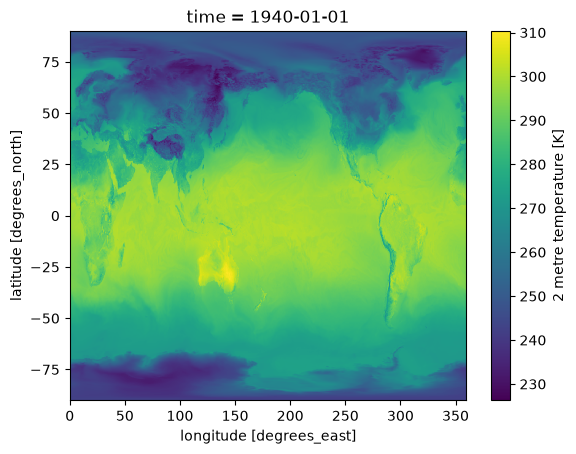

In [16]:
%%time
ds.VAR_2T.isel(time=0).plot()

### Close up the cluster

In [22]:
cluster.close()